In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math
import time

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}') # Should be cuda!

Using device: cuda


## 1.1 Setup

In [2]:
from torchvision.datasets import CIFAR100
from torchvision import transforms
from PIL import Image

BATCH_SIZE = 32

## Processing and normalization for CIFAR100 images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761])
])

train_dataset = CIFAR100(
    root="./",
    train=True,
    download=True,
    transform=transform
)
test_dataset = CIFAR100(
    root="./",
    train=False,
    download=True,
    transform=transform
)

print(len(train_dataset), len(test_dataset))

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, shuffle=True, batch_size=BATCH_SIZE)

# The mapping of numeric label to class name and vice-versa
label_to_class = {
    i:c for i,c in enumerate(train_dataset.classes)
}
class_to_label = {
  c:l for l,c in label_to_class.items()
}
print(label_to_class)

100%|██████████| 169M/169M [00:03<00:00, 47.7MB/s]


50000 10000
{0: 'apple', 1: 'aquarium_fish', 2: 'baby', 3: 'bear', 4: 'beaver', 5: 'bed', 6: 'bee', 7: 'beetle', 8: 'bicycle', 9: 'bottle', 10: 'bowl', 11: 'boy', 12: 'bridge', 13: 'bus', 14: 'butterfly', 15: 'camel', 16: 'can', 17: 'castle', 18: 'caterpillar', 19: 'cattle', 20: 'chair', 21: 'chimpanzee', 22: 'clock', 23: 'cloud', 24: 'cockroach', 25: 'couch', 26: 'crab', 27: 'crocodile', 28: 'cup', 29: 'dinosaur', 30: 'dolphin', 31: 'elephant', 32: 'flatfish', 33: 'forest', 34: 'fox', 35: 'girl', 36: 'hamster', 37: 'house', 38: 'kangaroo', 39: 'keyboard', 40: 'lamp', 41: 'lawn_mower', 42: 'leopard', 43: 'lion', 44: 'lizard', 45: 'lobster', 46: 'man', 47: 'maple_tree', 48: 'motorcycle', 49: 'mountain', 50: 'mouse', 51: 'mushroom', 52: 'oak_tree', 53: 'orange', 54: 'orchid', 55: 'otter', 56: 'palm_tree', 57: 'pear', 58: 'pickup_truck', 59: 'pine_tree', 60: 'plain', 61: 'plate', 62: 'poppy', 63: 'porcupine', 64: 'possum', 65: 'rabbit', 66: 'raccoon', 67: 'ray', 68: 'road', 69: 'rocket', 

## Below is provided code for attention layers. Note that in the ```TransformerBlock``` class, there is a ```use_causal_mask``` parameter that controls whether causal attention masking is applied in the layers.

In [3]:
class TransformerBlock(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout, use_causal_mask):
        super().__init__()

        self.use_causal_mask = use_causal_mask
        self.layer = nn.TransformerEncoderLayer(
            d_model=n_embd,
            nhead=n_head,
            dim_feedforward=4*n_embd,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

    def forward(self, x, attn_mask=None):

        if self.use_causal_mask:
          causal_mask = nn.Transformer.generate_square_subsequent_mask(x.shape[1]).to(device)
        else:
          causal_mask = None

        return self.layer(
            x,
            is_causal=self.use_causal_mask,
            src_mask = causal_mask,
            src_key_padding_mask = (attn_mask) if (attn_mask is not None) else None
        )

## 1.2 Vision Transformer Implementation

In [4]:
class ViTImageEncoder(nn.Module):
  def __init__(self, image_size=32, patch_size=4, num_classes=100, n_embd=128, n_layer=4, n_head=8, dropout=0.1):
    super().__init__()
    assert image_size % patch_size == 0, 'Image dimensions must be divisible by the patch size.'

    self.n_embd = n_embd
    self.num_patches = (image_size // patch_size) ** 2
    seq_len = self.num_patches + 1

    self.patch_embed = nn.Conv2d(3, n_embd, kernel_size=patch_size, stride=patch_size)
    self.cls_token = nn.Parameter(torch.zeros(1, 1, n_embd))
    self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, n_embd))
    self.drop = nn.Dropout(dropout)

    self.blocks = nn.ModuleList([
        TransformerBlock(n_embd, n_head, seq_len, dropout, use_causal_mask=False)
        for _ in range(n_layer)
    ])
    self.norm = nn.LayerNorm(n_embd)
    self.head = nn.Linear(n_embd, num_classes)

    nn.init.trunc_normal_(self.pos_embed, std=0.02)
    nn.init.trunc_normal_(self.cls_token, std=0.02)

  def get_image_features(self, x):
    B = x.shape[0]
    x = self.patch_embed(x)
    x = x.flatten(2).transpose(1, 2)

    cls_tokens = self.cls_token.expand(B, -1, -1)
    x = torch.cat((cls_tokens, x), dim=1)
    x = self.drop(x + self.pos_embed)

    for block in self.blocks:
      x = block(x, attn_mask=None)

    x = self.norm(x)
    return x[:, 0]

  def forward(self, x):
    return self.head(self.get_image_features(x))


## 1.3 ViT Training

In [5]:
def estimate_batch_vit_loss(model, batch):
    """Estimate train and val loss over eval_iters batches."""
    image_tensor, labels = batch
    image_tensor = image_tensor.to(device)
    labels = labels.to(device)
    logits = model(image_tensor)
    loss = F.cross_entropy(logits, labels)

    return loss

def estimate_batch_vit_acc(model, batch):
    """Estimate train and val loss over eval_iters batches."""
    image_tensor, labels = batch
    image_tensor = image_tensor.to(device)
    labels = labels.to(device)


    model.eval()
    with torch.no_grad():
      logits = model(image_tensor)
      correct = (torch.argmax(logits, dim=-1) == labels)
    return correct

def train_vit_model(model, max_iters, lr, eval_interval):
    """Training loop. Returns the model and a dict of logged losses."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    steps = []

    start_time = time.time()

    n_train_interval = 0
    loss_train_interval = 0
    correct_train_interval = 0

    iter= 0
    while True:
      if iter>max_iters:
        break
      for batch in train_loader:
          model.train()
          loss = estimate_batch_vit_loss(model, batch)
          correct = estimate_batch_vit_acc(model, batch)

          n_train_interval += len(batch[1])
          loss_train_interval += loss.detach().cpu().item()*len(batch[1])
          correct_train_interval += sum(correct).detach().cpu().item()

          optimizer.zero_grad(set_to_none=True)
          loss.backward()
          optimizer.step()

          iter+=1

          if iter>max_iters:
            break

          if iter % eval_interval == (eval_interval-1) or iter == max_iters - 1:
              train_loss = loss_train_interval / n_train_interval
              train_losses.append(train_loss)
              train_acc = correct_train_interval / n_train_interval
              train_accs.append(train_acc)

              n_train_interval = 0
              loss_train_interval = 0
              correct_train_interval = 0

              n_val = 0
              val_correct = 0
              val_loss = 0

              model.eval()
              for val_batch in test_loader:
                n_val += len(val_batch[1])
                with torch.no_grad():
                  val_batch_loss = estimate_batch_vit_loss(model, val_batch)
                  val_batch_correct = estimate_batch_vit_acc(model, val_batch)
                  val_loss += val_batch_loss*len(val_batch[1])
                  val_correct += sum(val_batch_correct).detach().cpu().item()
              val_loss /= n_val
              val_loss = val_loss.detach().cpu().item()
              val_acc = val_correct / n_val

              val_losses.append(val_loss)
              val_accs.append(val_acc)
              steps.append(iter)

              elapsed = time.time() - start_time
              print(f'Step {iter:5d} | train loss {train_loss:.4f} | train acc {train_acc:.4f} | val loss {val_loss:.4f} | val acc {val_acc:.4f} | time {elapsed:.1f}s')

    total_time = time.time() - start_time
    print(f'\nTraining complete in {total_time:.1f}s')

    return model, {'steps': steps, 'train_loss': train_losses, 'val_loss': val_losses, "train_acc": train_accs, "val_acc": val_accs}


def plot_metrics(log, metrics=["loss", "acc"]):
    """Plot training and validation curves."""
    for metric in metrics:
      plt.figure(figsize=(8, 4))
      plt.plot(log['steps'], log[f'train_{metric}'], label='Train')
      plt.plot(log['steps'], log[f'val_{metric}'], label='Val')
      plt.xlabel('Step')
      plt.ylabel(metric)
      plt.title(f'Training and Validation {metric}')
      plt.legend()
      plt.grid(True, alpha=0.3)
      plt.show()



In [16]:
MAX_ITERS = 10000
LR = 1e-4
EVAL_INTERVAL = 1000

vit_model = ViTImageEncoder(n_embd=128, n_layer=6, patch_size=4, n_head=4).to(device)
vit_model, log = train_vit_model(vit_model, MAX_ITERS, LR, EVAL_INTERVAL)

Step   999 | train loss 4.1610 | train acc 0.0694 | val loss 3.8936 | val acc 0.1037 | time 34.2s
Step  1999 | train loss 3.7631 | train acc 0.1289 | val loss 3.6285 | val acc 0.1467 | time 67.6s
Step  2999 | train loss 3.5075 | train acc 0.1696 | val loss 3.3698 | val acc 0.1970 | time 100.9s
Step  3999 | train loss 3.2802 | train acc 0.2142 | val loss 3.1624 | val acc 0.2270 | time 134.1s
Step  4999 | train loss 3.1033 | train acc 0.2464 | val loss 3.0202 | val acc 0.2512 | time 166.8s
Step  5999 | train loss 2.9485 | train acc 0.2753 | val loss 2.9229 | val acc 0.2669 | time 199.7s
Step  6999 | train loss 2.8348 | train acc 0.3015 | val loss 2.7950 | val acc 0.2940 | time 234.5s
Step  7999 | train loss 2.7627 | train acc 0.3161 | val loss 2.7297 | val acc 0.3076 | time 268.4s
Step  8999 | train loss 2.6617 | train acc 0.3338 | val loss 2.6420 | val acc 0.3223 | time 301.6s
Step  9999 | train loss 2.5799 | train acc 0.3527 | val loss 2.5665 | val acc 0.3378 | time 335.6s

Training co

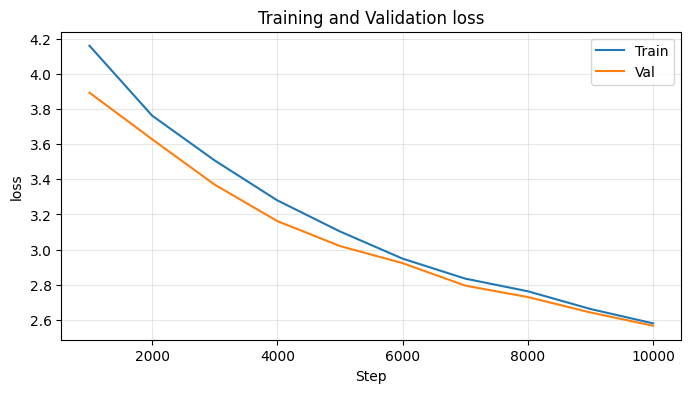

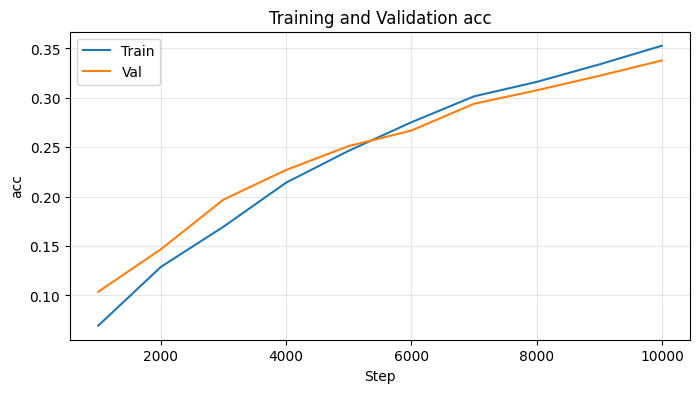

In [17]:
plot_metrics(log)

# 2. CLIP

## Character Vocabulary

Here the character vocabulary is defined manually. It will consist of only lowercase alphabetic characters. "-", ".", and "_" are used as the beginning-of-sentence, end-of-sentence, and padding tokens, respectively.


In [8]:
# Character-level tokenizer
import string

BOS_TOKEN = "-"
EOS_TOKEN = "."
PAD_TOKEN = "_"

chars = list(string.ascii_lowercase) + [" ", BOS_TOKEN, EOS_TOKEN, PAD_TOKEN]
vocab_size = len(chars)
print(f'Vocabulary size: {vocab_size}')
print(f'Characters: {"".join(chars)}')

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

EOS_TOKEN_ID = stoi[EOS_TOKEN]
PAD_TOKEN_ID = stoi[PAD_TOKEN]

Vocabulary size: 30
Characters: abcdefghijklmnopqrstuvwxyz -._


## 2.1 Text Encoder Implementation

Most of the text encoder is implemented for you. You will need to fill in the last part of the ```forward()``` function that returns the text embedding vector.

In [9]:

class TextEncoder(nn.Module):
    """A small text encoder model.

    This is the outer shell that combines:
    - Token embeddings
    - Learned positional embeddings
    - A stack of TransformerBlocks (which YOU will implement)
    - A final LayerNorm + linear head
    """
    def __init__(self, vocab_size, n_embd, block_size, n_head, n_layer, dropout):
        super().__init__()
        self.block_size = block_size

        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList(
            [
                TransformerBlock(n_embd, n_head, block_size, dropout, True) for _ in range(n_layer)
            ]
        )

        self.apply(self._init_weights)
        print(f'Model parameters: {sum(p.numel() for p in self.parameters()):,}')

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx):
        B, T = idx.shape
        assert T <= self.block_size, f'Sequence length {T} exceeds block size {self.block_size}'

        tok_emb = self.token_embedding(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding(pos)
        x = self.drop(tok_emb + pos_emb)

        pad_mask = idx == PAD_TOKEN_ID
        for block in self.blocks:
            x = block(x, attn_mask=pad_mask)

        eos_mask = idx == EOS_TOKEN_ID
        first_eos = (eos_mask.cumsum(dim=1) == 1) & eos_mask
        eos_idx = first_eos.long().argmax(dim=1)
        text_emb = x[torch.arange(B, device=x.device), eos_idx]
        return text_emb


## 2.3 CLIP Model Implementation


In the CLIPModel class, finish the implementations for ```forward()``` and ```clip_loss()``` functions.

In [10]:
MAX_LEN = 50

# Helper functions
def label_to_caption(label):
  if torch.is_tensor(label):
    label=label.item()
  class_ = label_to_class[label]
  caption = f"a photo of a {class_}"
  caption = f"-{caption}." # add bos and eos token
  return caption

def labels_to_text_tensor(labels):
  captions = [ label_to_caption(label) for label in labels ]
  max_len = max([len(caption) for caption in captions])
  padded_captions = [caption + PAD_TOKEN*(max_len-len(caption)) for caption in captions]
  text_tensor = torch.tensor(
      [encode(caption) for caption in padded_captions]
  )
  return text_tensor

class CLIPModel(nn.Module):
  def __init__(self, n_embd):
    super().__init__()
    self.image_encoder = ViTImageEncoder(n_embd=n_embd, n_layer=6, image_size=32, patch_size=4, n_head=4)
    self.text_encoder = TextEncoder(vocab_size=vocab_size, n_embd=n_embd, block_size=MAX_LEN, n_head=4, n_layer=4, dropout=0.1)
    self.temperature = nn.Parameter(torch.log(torch.tensor(1/0.07)))

  def forward(self, image_tensor, text_tensor):
    image_embeddings = self.image_encoder.get_image_features(image_tensor)
    text_embeddings = self.text_encoder(text_tensor)

    image_embeddings = F.normalize(image_embeddings, dim=-1)
    text_embeddings = F.normalize(text_embeddings, dim=-1)

    logit_scale = self.temperature.exp()
    logits = logit_scale * (image_embeddings @ text_embeddings.T)

    return image_embeddings, text_embeddings, logits

  def clip_loss(
    self,
    image_tensor,
    text_tensor
  ):
    image_embeddings, text_embeddings, logits = self.forward(image_tensor, text_tensor)

    B = image_tensor.shape[0]
    labels = torch.arange(B, device=image_tensor.device)
    loss_i = F.cross_entropy(logits, labels)
    loss_t = F.cross_entropy(logits.T, labels)
    loss = 0.5 * (loss_i + loss_t)

    return loss



## 2.5 CLIP Training
Train your CLIP model and plot the loss curve. You are free the experiment with different hyperparameters and even encoder architectures if you wish, but this given configuration should be a good default.


In [11]:
# Predefined training code; do not change
def estimate_batch_clip_loss(model, batch):
    """Estimate train and val loss over eval_iters batches."""
    image_tensor, labels = batch
    image_tensor = image_tensor.to(device)
    text_tensor = labels_to_text_tensor(labels).to(device)
    loss = model.clip_loss(image_tensor, text_tensor)
    return loss

def train_clip_model(model, max_iters, lr, eval_interval):
    """Training loop. Returns the model and a dict of logged losses."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    steps = []

    start_time = time.time()
    iter= 0

    n_train_interval = 0
    loss_train_interval = 0
    while True:
      if iter>max_iters:
        break
      for batch in train_loader:
          model.train()
          loss = estimate_batch_clip_loss(model, batch)

          loss_train_interval += loss.detach().cpu().item()*len(batch[1])
          n_train_interval += len(batch[1])

          optimizer.zero_grad(set_to_none=True)
          loss.backward()
          optimizer.step()

          iter+=1

          if iter>max_iters:
            break

          if iter % eval_interval == (eval_interval-1) or iter == max_iters - 1:
              train_loss = loss_train_interval / n_train_interval
              train_losses.append(train_loss)

              loss_train_interval = 0
              n_train_interval = 0

              n_val = 0
              val_loss = 0
              model.eval()
              with torch.no_grad():
                for val_batch in test_loader:
                  n_val += len(val_batch[1])
                  val_loss += (estimate_batch_clip_loss(model, val_batch)*len(val_batch[1]))
              val_loss /= n_val
              val_loss = val_loss.detach().cpu().item()

              val_losses.append(val_loss)
              steps.append(iter)

              elapsed = time.time() - start_time
              print(f'Step {iter:5d} | train loss {train_loss:.4f} | val loss {val_loss:.4f} | time {elapsed:.1f}s')

    total_time = time.time() - start_time
    print(f'\nTraining complete in {total_time:.1f}s')

    return model, {'steps': steps, 'train': train_losses, 'val': val_losses}


def plot_losses(log, title='Training and Validation Loss'):
    """Plot training and validation loss curves."""
    plt.figure(figsize=(8, 4))
    plt.plot(log['steps'], log['train'], label='Train')
    plt.plot(log['steps'], log['val'], label='Val')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [12]:
MAX_ITERS = 10000
LR = 1e-4
EVAL_INTERVAL = 1000

clip_model = CLIPModel(n_embd=128).to(device)
clip_model, log = train_clip_model(clip_model, MAX_ITERS, LR, EVAL_INTERVAL)

Model parameters: 803,328


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:823: UserWarning: Support for mismatched src_key_padding_mask and src_mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Step   999 | train loss 3.2695 | val loss 2.9359 | time 45.4s
Step  1999 | train loss 2.8421 | val loss 2.6266 | time 87.9s
Step  2999 | train loss 2.5805 | val loss 2.3717 | time 129.3s
Step  3999 | train loss 2.3778 | val loss 2.1797 | time 171.8s
Step  4999 | train loss 2.2202 | val loss 2.0892 | time 212.6s
Step  5999 | train loss 2.1245 | val loss 1.9796 | time 252.5s
Step  6999 | train loss 2.0210 | val loss 1.9240 | time 293.8s
Step  7999 | train loss 1.9553 | val loss 1.8524 | time 335.9s
Step  8999 | train loss 1.8879 | val loss 1.7885 | time 377.5s
Step  9999 | train loss 1.8452 | val loss 1.7651 | time 420.6s

Training complete in 420.7s


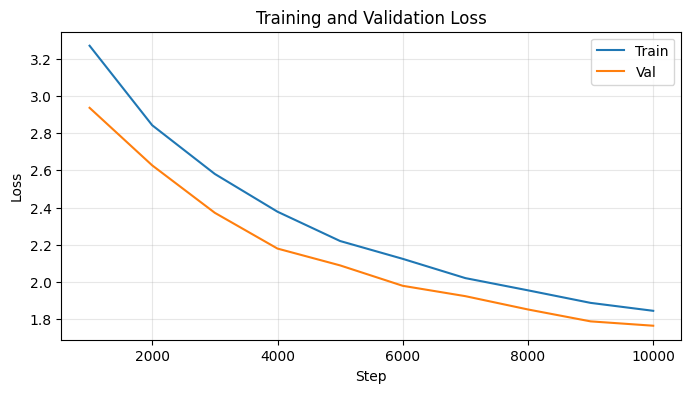

In [13]:
plot_losses(log)

## 2.6 Classification with CLIP

In this question, you will use your trained CLIP model to classify the CIFAR100 train and test set images and report the accuracy for each. Complete the ```classify_with_clip()``` function below.


In [14]:
def classify_with_clip(model, image_tensor):
  model.eval()
  with torch.no_grad():
    img_emb = model.image_encoder.get_image_features(image_tensor)
    img_emb = F.normalize(img_emb, dim=-1)

    class_ids = torch.arange(100, device=image_tensor.device)
    text_tensor = labels_to_text_tensor(class_ids).to(image_tensor.device)
    text_emb = model.text_encoder(text_tensor)
    text_emb = F.normalize(text_emb, dim=-1)

    logit_scale = model.temperature.exp()
    logits = logit_scale * (img_emb @ text_emb.T)
    pred_labels = logits.argmax(dim=-1)

  return pred_labels


n_correct = 0
n_total = 0
for image_tensor, labels in train_loader:
  image_tensor = image_tensor.to(device)
  pred_labels = classify_with_clip(clip_model, image_tensor).cpu()

  n_correct += sum(pred_labels == labels).item()
  n_total += image_tensor.shape[0]

print("Train Accuracy: ", n_correct/n_total)

n_correct = 0
n_total = 0
for image_tensor, labels in test_loader:
  image_tensor = image_tensor.to(device)
  pred_labels = classify_with_clip(clip_model, image_tensor).cpu()

  n_correct += sum(pred_labels == labels).item()
  n_total += image_tensor.shape[0]

print("Test Accuracy: ", n_correct/n_total)

Train Accuracy:  0.33962
Test Accuracy:  0.3083
